# HI (staircase): статистика по прогону

Вход: `carrot-like/data/sprout_prompts.json`. Результат: `staircase_cascade/output/staircase_eval.json` (имя совпадает с выводом `run_eval.py`; при необходимости поменяйте `EVAL_PATH` в следующей ячейке).


Ниже — среднее оценочное время устройства (сумма ступеней каскада, см. `mlx_device_profile`) и средняя оценка судьи (`quality_score` в JSON).


In [14]:
from pathlib import Path
import json

ROOT = Path.cwd().resolve().parent
EVAL_PATH = ROOT / "staircase_cascade" / "output" / "staircase_eval.json"

In [15]:
import numpy as np

raw = json.loads(EVAL_PATH.read_text(encoding="utf-8"))
n = len(raw)
times = np.array([r["staircase"]["total_device_seconds_est"] for r in raw], dtype=float)
scores = np.array([r["judge"]["quality_score"] for r in raw], dtype=float)

print(
    f"n={n} mean_device_s={times.mean():.4f} mean_judge_q={scores.mean():.4f} "
    f"median_device_s={np.median(times):.4f} median_judge_q={np.median(scores):.4f}"
)

n=200 mean_device_s=7.0966 mean_judge_q=0.7055 median_device_s=4.0950 median_judge_q=1.0000


### Каскад (HI) vs среднее по трём моделям

Для каждого промпта из прогона: оценка каскада — поле `judge.quality_score` в JSON прогона; база из трёх моделей — среднее арифметическое трёх офлайн-оценок `quality_score` (llama1b, llama3b, qwen7b) из `sprout_with_scores_judge.json` на том же промпте.

Ниже: среднее по запросам для каскада и для «средней тройки», плюс для справки средние по каждой модели на тех же сопоставленных промптах. Следующая ячейка — столбчатый сравнительный график.

In [16]:
QUALITY_FILE = ROOT / "carrot-like" / "data" / "sprout_with_scores_judge.json"
MODELS = ("llama1b", "llama3b", "qwen7b")


def _mean_q_three(item: dict) -> float | None:
    mdl = item.get("models") or {}
    qs = []
    for name in MODELS:
        block = mdl.get(name) or {}
        if "error" in block:
            continue
        if "quality_score" not in block:
            continue
        qs.append(float(block["quality_score"]))
    if len(qs) != len(MODELS):
        return None
    return float(np.mean(qs))


def _q_model(item: dict, name: str) -> float | None:
    block = (item.get("models") or {}).get(name) or {}
    if "error" in block or "quality_score" not in block:
        return None
    return float(block["quality_score"])


offline = json.loads(QUALITY_FILE.read_text(encoding="utf-8"))
by_prompt = {row["prompt"]: row for row in offline}

q_cascade_list = []
q_mean3_list = []
per_model = {m: [] for m in MODELS}
missing = 0
incomplete = 0

for row in raw:
    p = row.get("prompt", "")
    src = by_prompt.get(p)
    if src is None:
        missing += 1
        continue
    m3 = _mean_q_three(src)
    if m3 is None:
        incomplete += 1
        continue
    q_cascade_list.append(float(row["judge"]["quality_score"]))
    q_mean3_list.append(m3)
    for m in MODELS:
        qm = _q_model(src, m)
        if qm is not None:
            per_model[m].append(qm)

q_cascade_a = np.array(q_cascade_list, dtype=float)
q_mean3_a = np.array(q_mean3_list, dtype=float)

_n = len(q_cascade_a)
_pm = " ".join(
    f"{m}_mean_q={np.array(per_model[m], dtype=float).mean():.4f}"
    for m in MODELS
    if per_model[m]
)
print(
    f"matched={_n} missing_offline={missing} incomplete_offline={incomplete} "
    f"cascade_mean_q={q_cascade_a.mean():.4f} mean3_mean_q={q_mean3_a.mean():.4f} "
    f"diff_cascade_minus_mean3={q_cascade_a.mean() - q_mean3_a.mean():+.4f} {_pm}"
)

matched=200 missing_offline=0 incomplete_offline=0 cascade_mean_q=0.7055 mean3_mean_q=0.6995 diff_cascade_minus_mean3=+0.0060 llama1b_mean_q=0.5690 llama3b_mean_q=0.7205 qwen7b_mean_q=0.8090


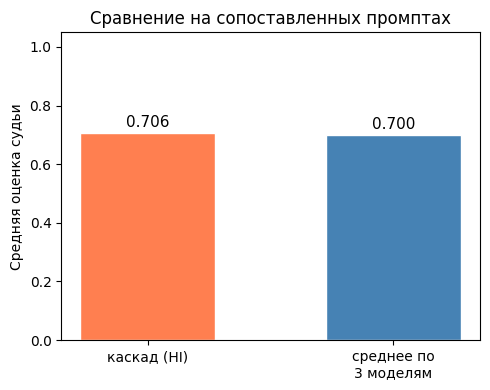

In [17]:
import matplotlib.pyplot as plt


labels = ["каскад (HI)", "среднее по\n3 моделям"]
means = [q_cascade_a.mean(), q_mean3_a.mean()]
colors = ["coral", "steelblue"]
fig, ax = plt.subplots(figsize=(5, 4))
x = np.arange(len(labels))
ax.bar(x, means, color=colors, edgecolor="white", width=0.55)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Средняя оценка судьи")
ax.set_title("Сравнение на сопоставленных промптах")
for i, v in enumerate(means):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()